<a href="https://colab.research.google.com/github/ranjanvrma/fraud-detection/blob/main/notebook/fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fraud Detection Benchmark Using Machine Learning

Made by: Ranjan Verma

This notebook analyzes fraudulent online payment transactions using supervised machine learning models and compares multiple algorithms to identify the best-performing model.

## Problem Statement

Online payment fraud causes significant financial losses. The objective of this project is to build and compare machine learning classification models that can accurately detect fraudulent transactions while minimizing missed fraud cases.

In [1]:
# Importing Required Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, RocCurveDisplay, ConfusionMatrixDisplay

import joblib

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/paysim.csv')

# Preprocessing Data

In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
print(df['type'].unique())

['PAYMENT' 'TRANSFER' 'CASH_OUT' 'DEBIT' 'CASH_IN']


In [6]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [7]:
df.drop(columns = ['nameOrig', 'nameDest', 'isFlaggedFraud'], axis = 1, inplace = True)

In [8]:
df.isnull().sum()

,0
step,0
type,0
amount,0
oldbalanceOrg,0
newbalanceOrig,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [9]:
df.duplicated().sum()

np.int64(543)

In [10]:
df = df.drop_duplicates()

In [11]:
df.shape

(6362077, 8)

In [12]:
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

# EDA

<Axes: >

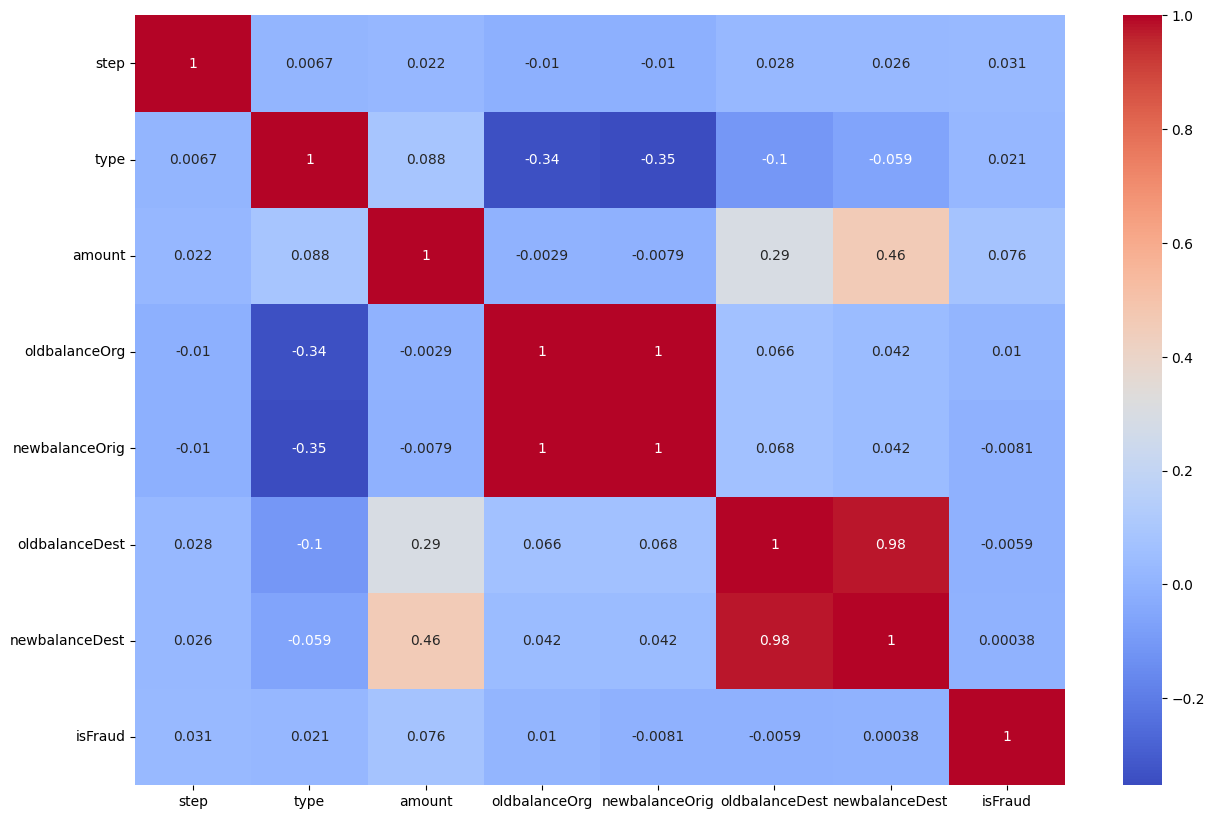

In [13]:
corr = df.corr()

plt.figure(figsize = (15, 10))
sns.heatmap(corr, annot = True, cmap = 'coolwarm')

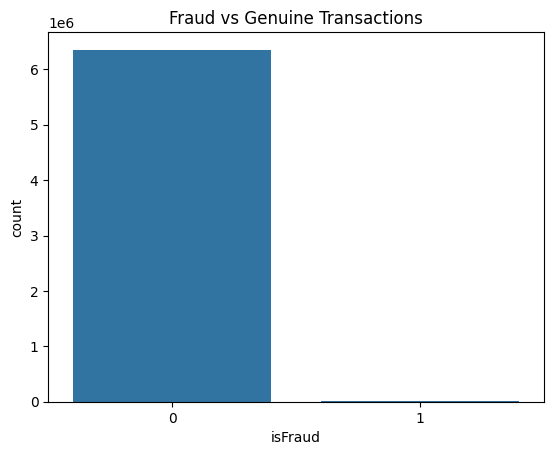

In [14]:
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Genuine Transactions")
plt.show()

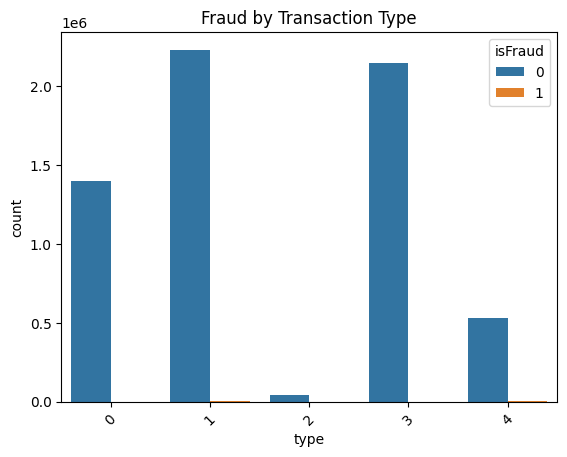

In [15]:
sns.countplot(x='type', hue='isFraud', data=df)
plt.title("Fraud by Transaction Type")
plt.xticks(rotation=45)
plt.show()

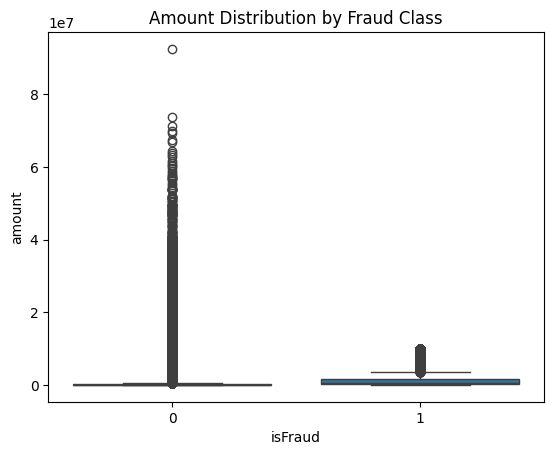

In [16]:
sns.boxplot(x='isFraud', y='amount', data=df)
plt.title("Amount Distribution by Fraud Class")
plt.show()

# Feature Engineering

In [17]:
df["amount_to_balance_ratio"] = df["amount"] / (df["oldbalanceOrg"] + 1)

df["sender_drained"] = (
    df["newbalanceOrig"] < 0.1 * df["oldbalanceOrg"]
).astype(int)

df["dest_was_zero"] = (
    df["oldbalanceDest"] == 0
).astype(int)

df["balance_error_orig"] = (
    df["oldbalanceOrg"] - df["newbalanceOrig"] - df["amount"]
)

df["balance_error_dest"] = (
    df["newbalanceDest"] - df["oldbalanceDest"] - df["amount"]
)

# Splitting the Dataset

In [18]:
X = df.drop('isFraud', axis = 1)
y = df['isFraud']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify=y
)

In [20]:
# Using less data to decrease computing power
X_train_small = X_train.sample(300000, random_state=42)
y_train_small = y_train.loc[X_train_small.index]

In [21]:
df

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,amount_to_balance_ratio,sender_drained,dest_was_zero,balance_error_orig,balance_error_dest
0,1,3,9839.64,170136.00,160296.36,0.00,0.00,0,0.057834,0,1,1.455192e-11,-9.839640e+03
1,1,3,1864.28,21249.00,19384.72,0.00,0.00,0,0.087731,0,1,-1.136868e-12,-1.864280e+03
2,1,4,181.00,181.00,0.00,0.00,0.00,1,0.994505,1,1,0.000000e+00,-1.810000e+02
3,1,1,181.00,181.00,0.00,21182.00,0.00,1,0.994505,1,0,0.000000e+00,-2.136300e+04
4,1,3,11668.14,41554.00,29885.86,0.00,0.00,0,0.280788,0,1,0.000000e+00,-1.166814e+04
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,1,339682.13,339682.13,0.00,0.00,339682.13,1,0.999997,1,1,0.000000e+00,0.000000e+00
6362616,743,4,6311409.28,6311409.28,0.00,0.00,0.00,1,1.000000,1,1,0.000000e+00,-6.311409e+06
6362617,743,1,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,1.000000,1,0,0.000000e+00,-1.000000e-02
6362618,743,4,850002.52,850002.52,0.00,0.00,0.00,1,0.999999,1,1,0.000000e+00,-8.500025e+05


# Training Models

## Random Forest

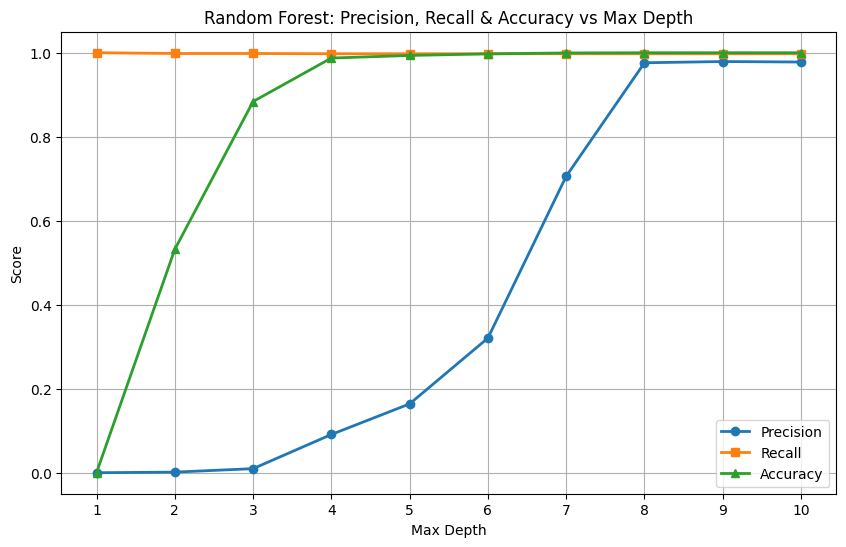

In [44]:
depths = range(1, 11)

precision_scores = []
recall_scores = []
accuracy_scores = []

for d in depths:

    rf = RandomForestClassifier(criterion='gini', max_depth=d, random_state=42, n_estimators = 30, n_jobs = -1, class_weight='balanced')
    rf.fit(X_train_small, y_train_small)

    y_prob = rf.predict_proba(X_test)[:,1]
    y_pred = (y_prob >= 0.10).astype(int)

    precision_scores.append(precision_score(y_test, y_pred))
    recall_scores.append(recall_score(y_test, y_pred))
    accuracy_scores.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(10,6))

plt.plot(depths, precision_scores, marker='o', linewidth=2, label='Precision')
plt.plot(depths, recall_scores, marker='s', linewidth=2, label='Recall')
plt.plot(depths, accuracy_scores, marker='^', linewidth=2, label='Accuracy')

plt.xlabel("Max Depth")
plt.ylabel("Score")
plt.title("Random Forest: Precision, Recall & Accuracy vs Max Depth")
plt.xticks(depths)
plt.legend()
plt.grid(True)
plt.show()

We are getting best and Reasonable results at max_depth 8

In [45]:
rf = RandomForestClassifier(criterion='gini', max_depth=8, random_state=42, n_estimators = 100, n_jobs = -1, class_weight='balanced')
rf.fit(X_train_small, y_train_small)

RandomForestClassifier(class_weight='balanced', max_depth=8, n_jobs=-1,
                       random_state=42)

In [46]:
y_prob = rf.predict_proba(X_test)[:,1]
y_pred = (y_prob >= 0.10).astype(int)

In [47]:
print("Random Forest")

print("Accuracy Score: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Random Forest
Accuracy Score:  0.9999512737972487
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270777
           1       0.97      1.00      0.98      1639

    accuracy                           1.00   1272416
   macro avg       0.98      1.00      0.99   1272416
weighted avg       1.00      1.00      1.00   1272416



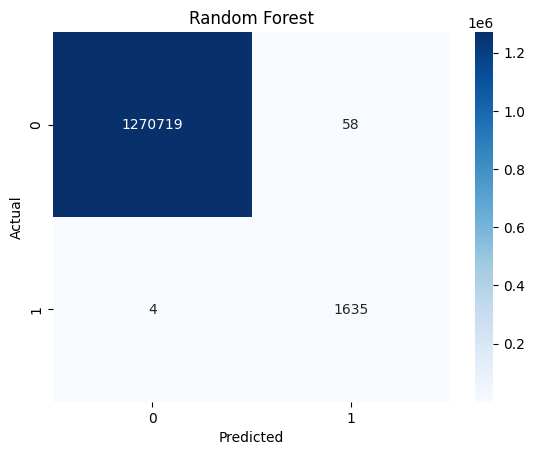

In [48]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

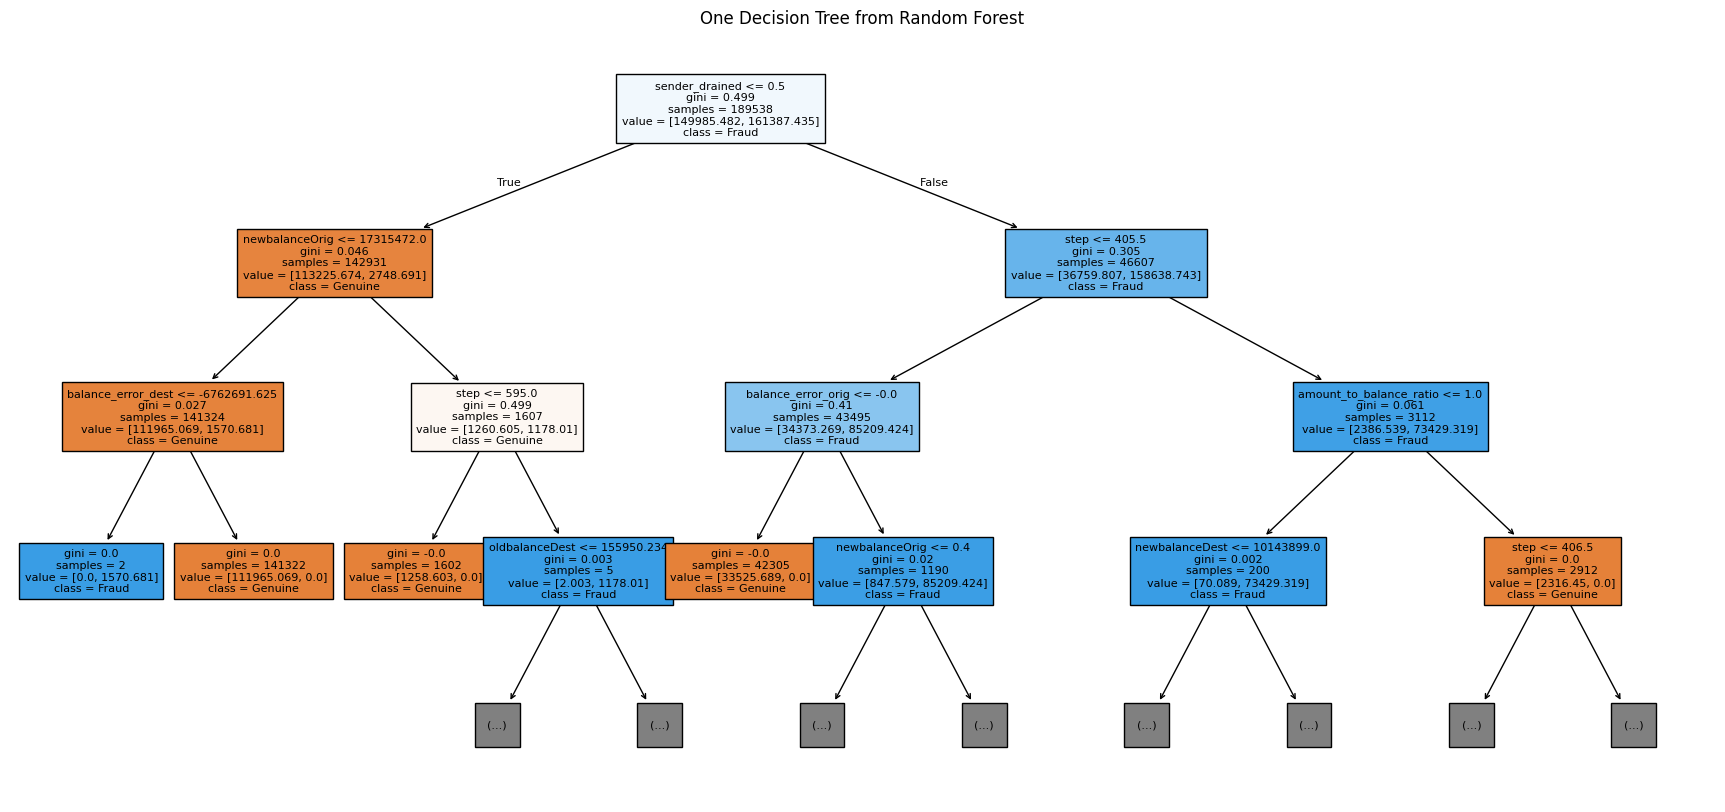

In [38]:
plt.figure(figsize=(22,10))
plot_tree(
    rf.estimators_[0],
    feature_names=X.columns,
    class_names=['Genuine','Fraud'],
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title("One Decision Tree from Random Forest")
plt.show()

Since the dataset is highly imbalanced, Precision, Recall, F1-score, and ROC-AUC were prioritized over Accuracy.

In [41]:
joblib.dump(rf, "/content/fraud_model.pkl")
joblib.dump(list(X.columns), "/content/model_columns.pkl")

['/content/model_columns.pkl']

##Conclusion:
Feature engineering significantly improved fraud detection performance.
Random Forest with max_depth=4 delivered strong precision-recall balance.
Model was exported for Streamlit deployment.